<a href="https://colab.research.google.com/github/patibandlasaipavan-beep/Supervised_learning_diabetics_identification/blob/model_validation/diabetes_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Understanding the data:

## Columns:
*   **Pregnancies**
*   **Glucose**
*   **BloodPressure**
*   **SkinThickness**
*   **Insulin**
*   **BMI**
*   **DiabetesPedigreeFunction**
*   **Age**
*   **Outcome**

## DiabetesPedigreeFunction:
The DiabetesPedigreeFunction (DPF) is a specialized genetic score used in the dataset to estimate a patient's hereditary risk for diabetes. Instead of just looking at whether a single relative had diabetes, it uses a mathematical formula that factors in how closely related the patient is to family members who have the disease, alongside those relatives' ages.


### Understanding the Scores
*   **Higher Score = Stronger Genetic Link**: A higher value (up to the dataset's maximum of 2.42) indicates a rich family history of diabetes, making the patient genetically more predisposed to developing the condition.
*   **Lower Score = Weaker Genetic Link**: A lower value (down to the dataset's minimum of 0.078) indicates very little to no history of diabetes among close relatives.

## BMI:
BMI is calculated by dividing a person's weight by the square of their height.

## Other columns and their limits:

| Variable            | Lower Limit (Min) | Upper Limit (Max) | Unit     |
| :------------------ | :---------------- | :---------------- | :------- |
| Glucose             | 44                | 199               | mg/dL    |
| Insulin             | 14                | 46                | mu U/mL  |
| BloodPressure       | 24                | 122               | mm Hg    |
| SkinThickness       | 7.0               | 99.0              | mm       |
| BMI                 | 18.2              | 67.1              | kg/m²    |
|Outcome              | 0 (non diabetic) | 1(diabetic)

In [ ]:
import pandas as pd
import numpy as np
import copy
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,roc_auc_score,f1_score,average_precision_score
from sklearn.preprocessing import StandardScaler,FunctionTransformer
from sklearn.model_selection import GridSearchCV
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold,cross_validate
from sklearn.pipeline import Pipeline


In [ ]:
# Load csv data into dataframe. Please ensure 'diabetes.csv' is uploaded to your Colab environment or provide the correct path.
df=pd.read_csv("/diabetes.csv")

In [ ]:
#Analyse DATA
print("Top 5 records")
print(df.head())
print("------------------------------------------------------------------------------\n")
print("Data information")
print(df.info())
print("------------------------------------------------------------------------------\n")
print("Data shape")
print(df.shape)
print("------------------------------------------------------------------------------\n")
print("Null values")
print(df.isna().sum())
print("------------------------------------------------------------------------------\n")
print("Duplicate values")
print(df.duplicated().sum())
print("------------------------------------------------------------------------------\n")
print("Data description")
df.describe()


Top 5 records
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
------------------------------------------------------------------------------

Data information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


From Data Description, it is evident that there are no null or duplicate records but Glucose, Blood pressure, skinthickness, Insulin and BMI columns minumum values are zero which is either because of human error or missed vaules.

These zero value records should be treated by replacing by null value rather the deletion of records to avoid data loss.

In [ ]:
#Take copy of dataframe
df_non_zero =copy.deepcopy(df)
#replace zero columns to null values
non_zero_columns=["Glucose","BloodPressure","SkinThickness","Insulin","BMI","Age"]
df_non_zero[non_zero_columns]=np.where(df_non_zero[non_zero_columns]<=0,np.nan,df_non_zero[non_zero_columns])
print(df_non_zero.isna().sum())


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


Below columns has high number of null values:

SkinThickness         -      227

Insulin       -              374

Outcome
0    500
1    268
Name: count, dtype: int64


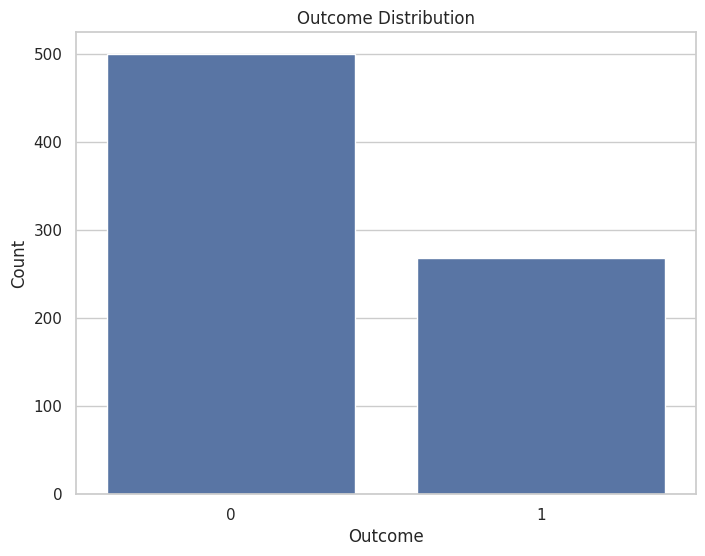

In [ ]:
#Diabetes Outcome Distribution
print(df_non_zero['Outcome'].value_counts())
#plot outome distribution with count
plt.figure(figsize=(8,6))
sns.countplot(x='Outcome',data=df_non_zero,stat="count")
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Outcome Distribution')
plt.show()

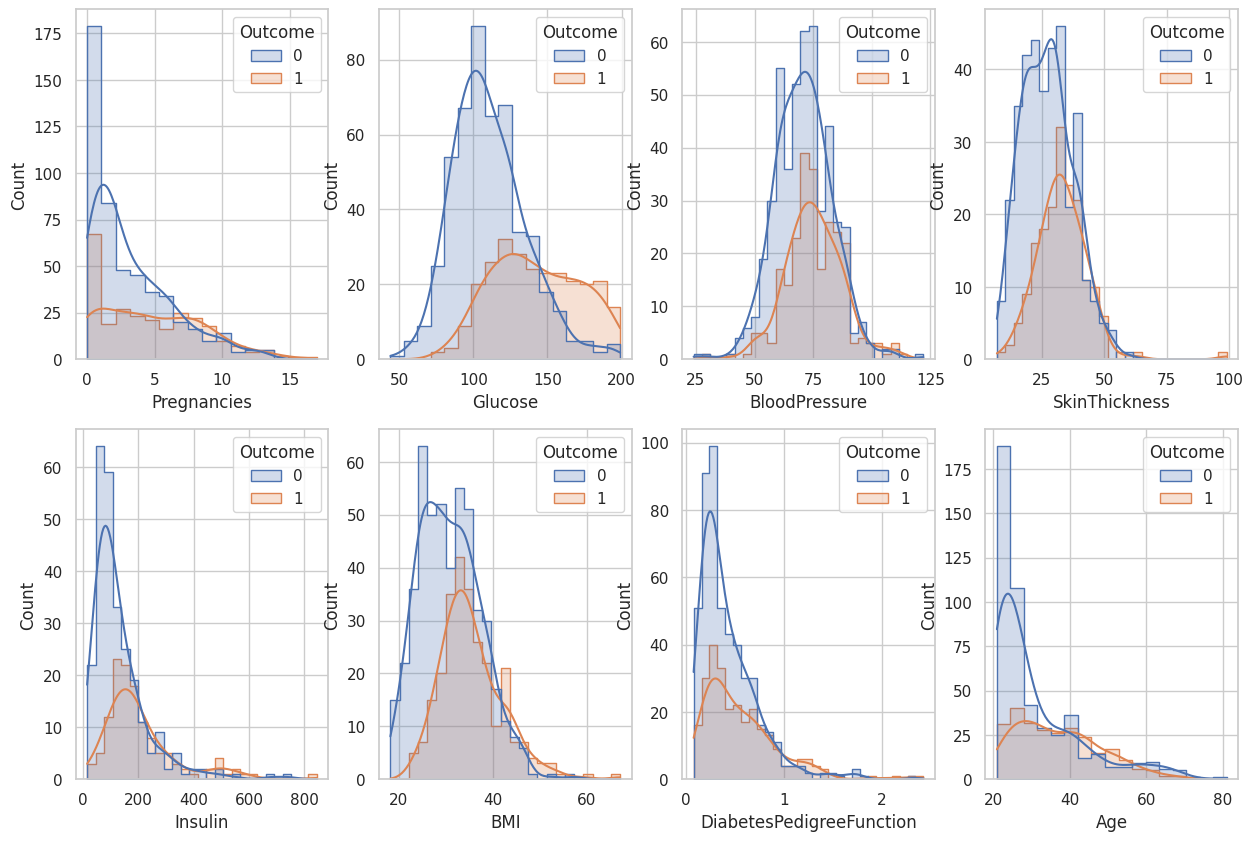

In [ ]:
#feature Distibution - histogram plot

feature_columns=["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]
figure,axes = plt.subplots(nrows=2,ncols=4,figsize=(15,10))
axes=axes.flatten()
for column,ax in zip(feature_columns,axes):
    sns.histplot(x=column,data=df_non_zero,ax=ax,hue=df_non_zero['Outcome'],element='step',kde=True)
    plt.show


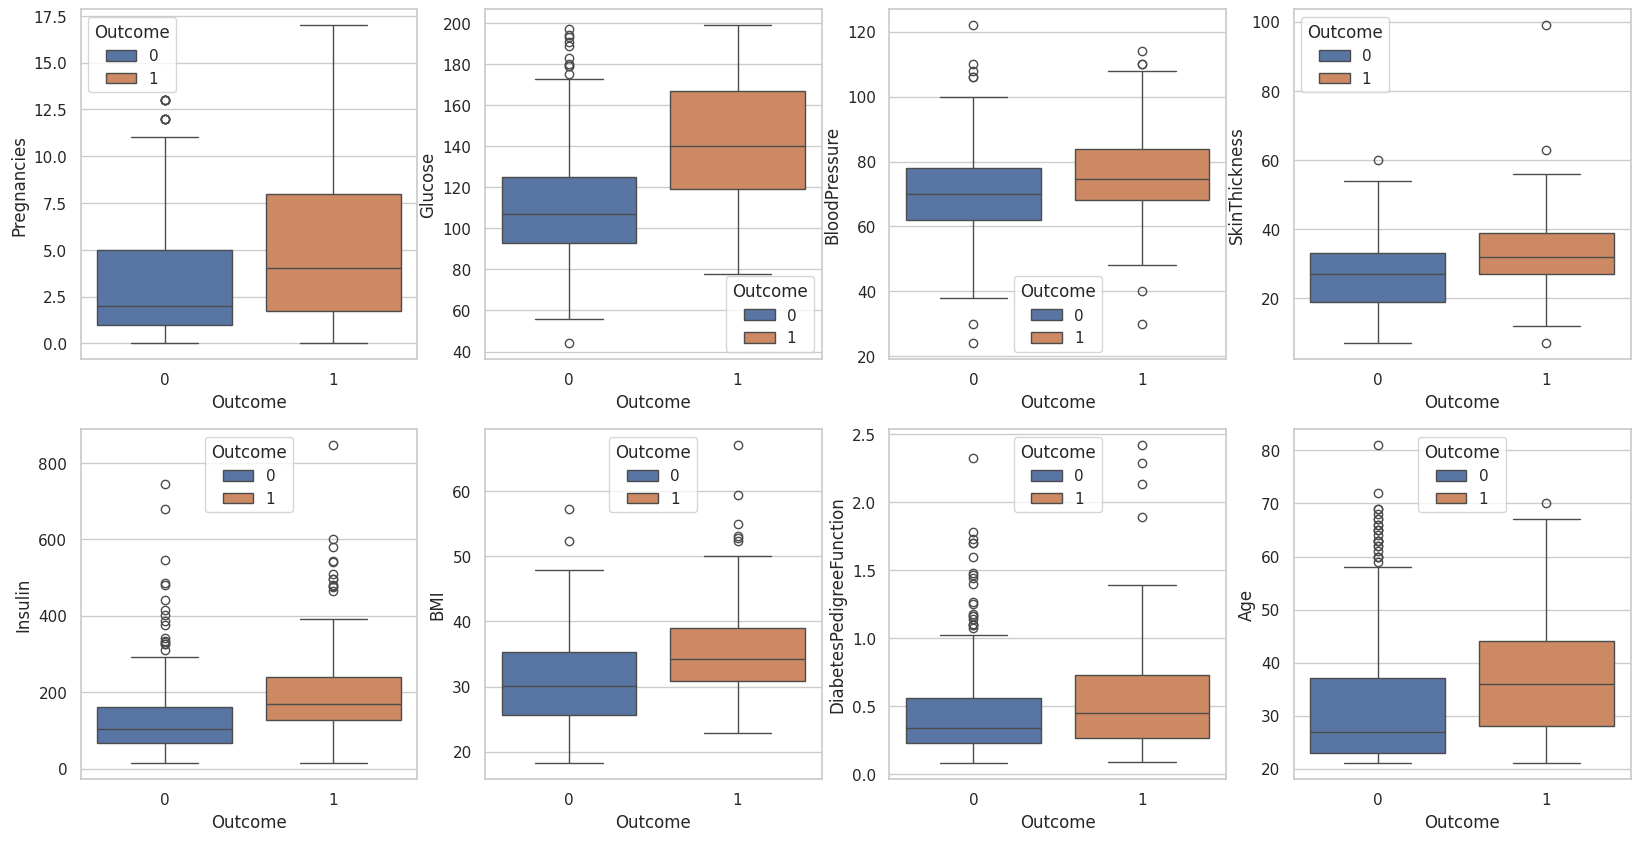

In [ ]:
#As feature distribution is skewed with outliers, lets box plot wrt to outcome
figure,axes = plt.subplots(nrows=2,ncols=4,figsize=(20,10))
axes=axes.flatten()
for column,ax in zip(feature_columns,axes):
    sns.boxplot(x='Outcome',y=column,data=df_non_zero,ax=ax,hue=df_non_zero['Outcome'])
    plt.show


In [ ]:

#build outlier report
for column in feature_columns:
  values= df_non_zero[column].dropna()
  first_quartile,third_quartile=np.percentile(values,[25,75])
  iqr=third_quartile-first_quartile
  lower_bound=first_quartile-(1.5*iqr)
  upper_bound=third_quartile+(1.5*iqr)
  count = ((values < lower_bound) | (values > upper_bound)).sum()
  print(f"{column} has {count} outliers. lower bound is {round(lower_bound,3)} and upper bound is {round(upper_bound,3)}")
#

Pregnancies has 4 outliers. lower bound is -6.5 and upper bound is 13.5
Glucose has 0 outliers. lower bound is 36.0 and upper bound is 204.0
BloodPressure has 14 outliers. lower bound is 40.0 and upper bound is 104.0
SkinThickness has 3 outliers. lower bound is 1.0 and upper bound is 57.0
Insulin has 24 outliers. lower bound is -94.375 and upper bound is 360.625
BMI has 8 outliers. lower bound is 13.85 and upper bound is 50.25
DiabetesPedigreeFunction has 29 outliers. lower bound is -0.33 and upper bound is 1.2
Age has 9 outliers. lower bound is -1.5 and upper bound is 66.5


# Outliers Report

Pregnancies has 4 outliers.

Glucose has 0 outliers.

BloodPressure has 14 outliers.

SkinThickness has 3 outliers.

Insulin has 24 outliers.

BMI has 8 outliers.

DiabetesPedigreeFunction has 29 outliers.

Age has 9 outliers.

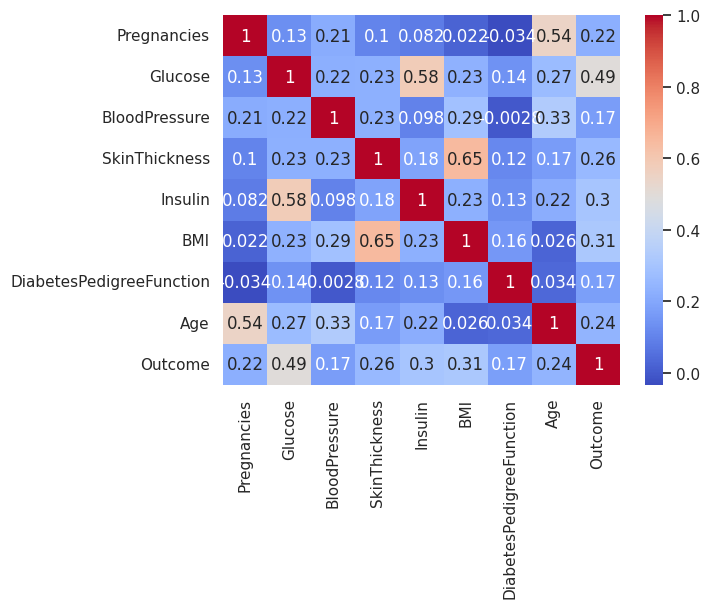

In [ ]:
#feature correlation matrix
corr_matrix=df_non_zero.corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.show()

From the correlation matrix,

It is found that Glucose (0.49), BMI (0.31), and SkinThickness (0.26) have good positive correlation to Outcome.

## Exploratory Data Analysis (EDA) Summary

### 1. Data Overview
*   **Dimensions**: The dataset contains 768 records and 9 features.
*   **Missing Values**: Initially, no explicit missing values were present. However, after replacing biologically implausible zero values (in 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI') with NaN, we observed significant missing values, particularly in 'Insulin' (374) and 'SkinThickness' (227).
*   **Duplicates**: No duplicate records were found.

### 2. Outcome Distribution
*   The `Outcome` variable shows an imbalance: 500 individuals are non-diabetic (0) and 268 are diabetic (1). This imbalance will need to be considered during model training.

### 3. Feature Distributions and Outliers
*   **Skewness**: Most numerical features exhibit a right-skewed distribution, indicating a concentration of values at the lower end with a tail extending towards higher values.
*   **Outliers**: Several features contain outliers, as identified by the box plots and the outlier report. Notably:
    *   `Pregnancies`: 4 outliers.
    *   `BloodPressure`: 14 outliers.
    *   `Insulin`: 24 outliers (highest among the features).
    *   `BMI`: 8 outliers.
    *   `DiabetesPedigreeFunction`: 29 outliers.
    *   `Age`: 9 outliers.
*   **Impact on Outcome**: Box plots comparing features against the `Outcome` variable suggest that higher values in `Glucose`, `BMI`, `Age`, and `DiabetesPedigreeFunction` tend to be associated with a positive diabetes outcome (1).

### 4. Feature Correlation
*   The correlation matrix reveals the following strong positive correlations with the `Outcome` variable:
    *   `Glucose`: 0.49
    *   `BMI`: 0.31
    *   `SkinThickness`: 0.26
*   `Pregnancies` and `Age` also show moderate positive correlations with `Outcome` (0.22 and 0.24 respectively). These features are likely strong predictors for diabetes.

AS Dataset is small, outlier can represent rare or uncertain cases, Hence Outlier will not be removed.

In [ ]:
df_non_zero.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Feature Engineering:

Insulin and SkinThickness have high null or zero values. Create indicator columns like `insulin_missing`, `skinThickness_missing` and impute with the median of the data.

Fit the model without Insulin, and without Insulin and SkinThickness, and validate across different supervised learning models.

In [ ]:
#Seperate Predictors from output
all_features = df[feature_columns].copy()
features_without_insulin=all_features.drop('Insulin',axis=1)
features_without_insulin_skinThichness=features_without_insulin.drop('SkinThickness',axis=1)
target= df['Outcome'].copy()
features={
    "all_features":all_features,
    "features_without_insulin":features_without_insulin,
    "features_without_insulin_skinThichness":features_without_insulin_skinThichness
}
indicator_columns=['Insulin','SkinThickness']


In [ ]:
def prepare_fold_features(fold_features: pd.DataFrame) -> pd.DataFrame:
  """Create Indicators and replace invalide zero to null values"""
  prepared = fold_features.copy()
  for column in indicator_columns:
    if column in prepared.columns:
       prepared[column+"_missing"]=(prepared[column]==0 | prepared[column].isna()).astype(int)
  non_zero_valid_columns=list(set(non_zero_columns).intersection(set(prepared.columns)))
  prepared[non_zero_valid_columns]=prepared[non_zero_valid_columns].replace(0,np.nan)
  return prepared



Impute Zero values with median for features insulin and SkinThickness.

Scale the features to fit in the below models

Logistic regression

1.   Logistic regression
2.   Decision Tree
3.   Random Forest
4.   KNN Classifier



In [ ]:
# Define the base preprocessing pipeline without the model step
preprocessing_pipeline = Pipeline(steps=[
    ('prepare', FunctionTransformer(prepare_fold_features, validate=False)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Define a dictionary of target estimators to test
models_to_test = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8, min_samples_leaf=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),

}



Split train and test data in 5 stratified folds in 80:20 ratio using StratifiedKFold class.

In [ ]:
# Shuffle data randomly with maintaing stratified sampling
validation_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
validation_scores ={
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "pr_auc": "average_precision",
}


In [ ]:
from sklearn import metrics
#cross_validate fits five independent copies and reurns on test score per fold
validation_summary_rows=[]
for features_data in features.keys():
  for model_name, model_estimator in models_to_test.items():
      # Dynamically build a complete pipeline
      full_pipeline = Pipeline(steps=[
          ('preprocessing', preprocessing_pipeline),
          ('model', model_estimator)
      ])

      # Evaluate with stratified 5-fold cross-validation
      validation_results = cross_validate(
          full_pipeline,
          features[features_data],
          target,
          cv=validation_folds,
          scoring=validation_scores
      )
      metrics=dict()
      for metric_name in validation_scores.keys():
        values= validation_results[f"test_{metric_name}"]
        mean_value= float(values.mean())
        metrics[metric_name]=mean_value
        metrics[metric_name+'_standard_deviation']=float(values.std())
      metrics["model"]=model_name+"_"+features_data
      print(metrics)
      validation_summary_rows.append(metrics)



{'accuracy': 0.7656141244376539, 'accuracy_standard_deviation': 0.024401148362798854, 'precision': 0.7143353759452831, 'precision_standard_deviation': 0.0667785549683113, 'recall': 0.559958071278826, 'recall_standard_deviation': 0.035293535466474645, 'roc_auc': 0.8373116701607268, 'roc_auc_standard_deviation': 0.022325036911825948, 'f1': 0.6254796690723464, 'f1_standard_deviation': 0.029028618509402308, 'pr_auc': 0.7208515769970376, 'pr_auc_standard_deviation': 0.038373544275164144, 'model': 'Logistic Regression_all_features'}
{'accuracy': 0.7681860623037093, 'accuracy_standard_deviation': 0.01471737618572252, 'precision': 0.6937929698928343, 'precision_standard_deviation': 0.0330388359801576, 'recall': 0.6044723969252271, 'recall_standard_deviation': 0.04002491214263476, 'roc_auc': 0.8349958071278826, 'roc_auc_standard_deviation': 0.02151938013038433, 'f1': 0.6449172672542329, 'f1_standard_deviation': 0.025913304025894528, 'pr_auc': 0.7143104758960251, 'pr_auc_standard_deviation': 0.0

In [ ]:
valiadtion_df= pd.DataFrame(validation_summary_rows)
valiadtion_df.head( n=20)

,accuracy,accuracy_standard_deviation,precision,precision_standard_deviation,recall,recall_standard_deviation,roc_auc,roc_auc_standard_deviation,f1,f1_standard_deviation,pr_auc,pr_auc_standard_deviation,model
0,0.765614,0.024401,0.714335,0.066779,0.559958,0.035294,0.837312,0.022325,0.625480,0.029029,0.720852,0.038374,Logistic Regression_all_features
1,0.768186,0.014717,0.693793,0.033039,0.604472,0.040025,0.834996,0.021519,0.644917,0.025913,0.714310,0.020262,Random Forest_all_features
2,0.730337,0.044939,0.649093,0.086685,0.563522,0.110303,0.775023,0.033447,0.590833,0.053659,0.608098,0.045855,Decision Tree_all_features
3,0.722596,0.025914,0.614144,0.041598,0.551992,0.050501,0.762596,0.017285,0.580754,0.043117,0.584995,0.021962,KNN_all_features
4,0.769502,0.014475,0.720965,0.052583,0.563522,0.023511,0.837948,0.019710,0.630695,0.009633,0.721847,0.035855,Logistic Regression_features_without_insulin
5,0.759061,0.022726,0.690359,0.052689,0.567086,0.033173,0.830609,0.020797,0.621695,0.033170,0.702034,0.034356,Random Forest_features_without_insulin
6,0.736847,0.045833,0.655905,0.083827,0.567156,0.110354,0.787368,0.039898,0.597882,0.064812,0.633972,0.045723,Decision Tree_features_without_insulin
7,0.712206,0.019930,0.595943,0.033886,0.544444,0.046754,0.761355,0.018963,0.568333,0.036597,0.582260,0.023184,KNN_features_without_insulin
8,0.770800,0.014981,0.721622,0.058406,0.571069,0.037258,0.837968,0.019889,0.634801,0.015191,0.729020,0.037907,Logistic Regression_features_without_insulin_s...
9,0.766845,0.033869,0.699001,0.060930,0.581691,0.055356,0.834593,0.032281,0.634743,0.056840,0.724288,0.024536,Random Forest_features_without_insulin_skinThi...


Plot mean ROC_LUC scores, F1 scores with standard deviation across differnt models and features to compare the validation and identifing best modules

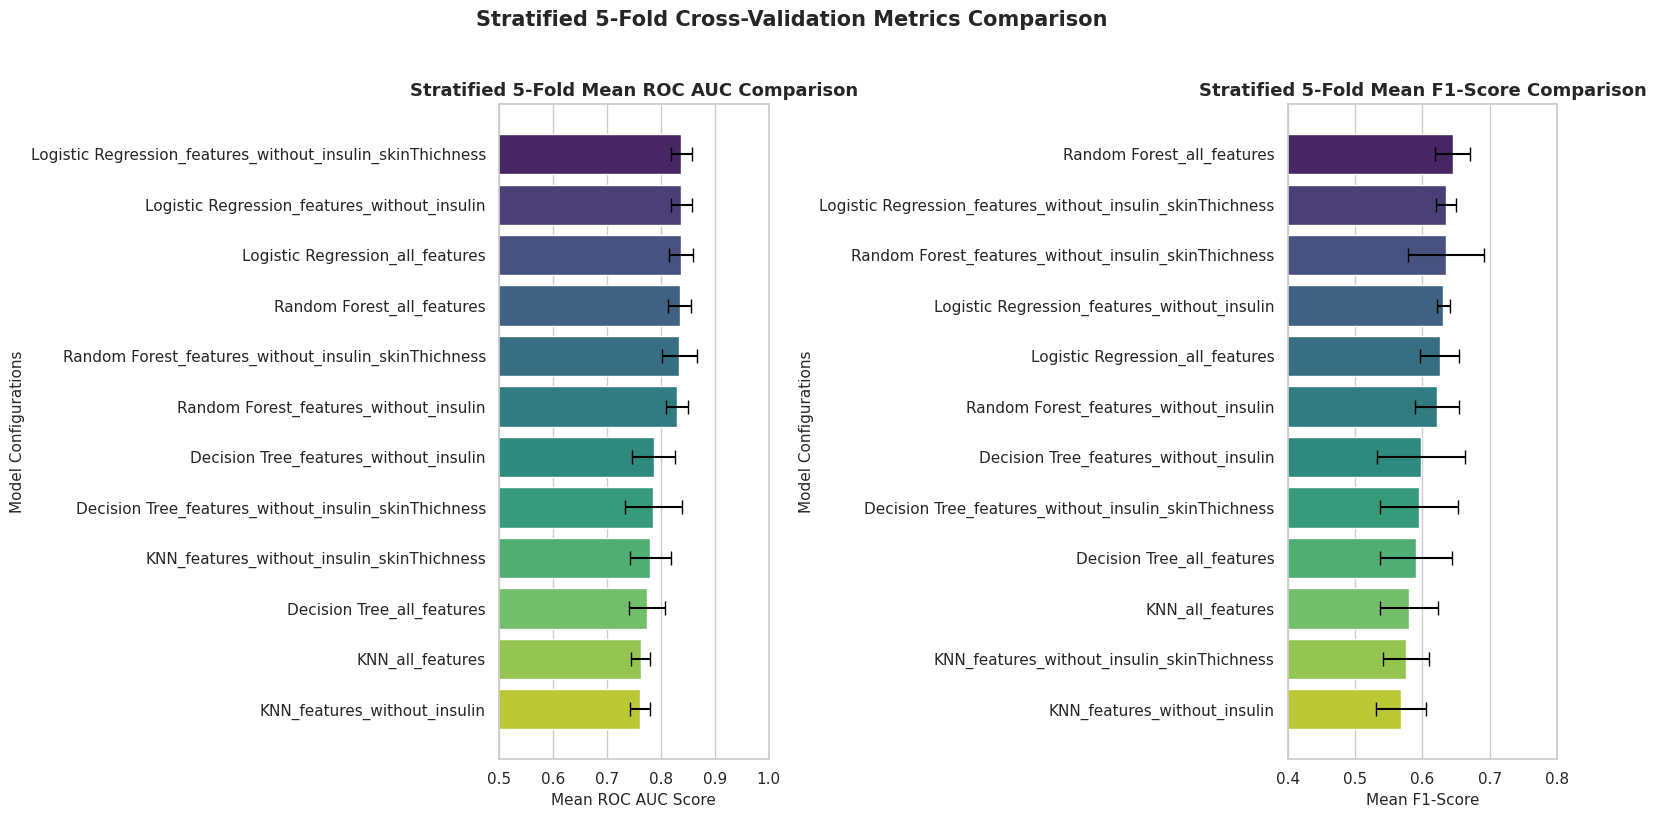

-------------------------------------------------------------------------------------------------------
Random Forest_all_features



,f1,accuracy,roc_auc,roc_auc_standard_deviation
1,0.644917,0.768186,0.834996,0.021519



Logistic Regression_features_without_insulin_skinThichness



,f1,accuracy,roc_auc,roc_auc_standard_deviation
8,0.634801,0.7708,0.837968,0.019889


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sort the dataframes independently for each metric in descending order
roc_auc_sorted_df = valiadtion_df.sort_values(by='roc_auc', ascending=False)
f1_sorted_df = valiadtion_df.sort_values(by='f1', ascending=False)

# 2. Set up side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.set_theme(style="whitegrid")

# Subplot 1: ROC AUC Comparison (Sorted Descending)
sns.barplot(
    x='roc_auc',
    y='model',
    data=roc_auc_sorted_df,
    hue='model',
    palette='viridis',
    legend=False,
    ax=axes[0]
)
axes[0].errorbar(
    x=roc_auc_sorted_df['roc_auc'],
    y=range(len(roc_auc_sorted_df)),
    xerr=roc_auc_sorted_df['roc_auc_standard_deviation'],
    fmt='none',
    c='black',
    capsize=5
)
axes[0].set_title('Stratified 5-Fold Mean ROC AUC Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Model Configurations', fontsize=11)
axes[0].set_xlabel('Mean ROC AUC Score', fontsize=11)
axes[0].set_xlim(0.5, 1.0)

# Subplot 2: F1-Score Comparison (Sorted Descending)
sns.barplot(
    x='f1',
    y='model',
    data=f1_sorted_df,
    hue='model',
    palette='viridis',
    legend=False,
    ax=axes[1]
)
axes[1].errorbar(
    x=f1_sorted_df['f1'],
    y=range(len(f1_sorted_df)),
    xerr=f1_sorted_df['f1_standard_deviation'],
    fmt='none',
    c='black',
    capsize=5
)
axes[1].set_title('Stratified 5-Fold Mean F1-Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Model Configurations', fontsize=11)
axes[1].set_xlabel('Mean F1-Score', fontsize=11)
axes[1].set_xlim(0.4, 0.8)

plt.suptitle('Stratified 5-Fold Cross-Validation Metrics Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("-------------------------------------------------------------------------------------------------------")
# To select multiple columns, wrap the column names in a list (using double brackets)
print('Random Forest_all_features\n')
rf_all=valiadtion_df[valiadtion_df['model'] == 'Random Forest_all_features'][['f1', 'accuracy','roc_auc','roc_auc_standard_deviation']]
display(rf_all)

print('\nLogistic Regression_features_without_insulin_skinThichness\n')
lr_reduced=valiadtion_df[valiadtion_df['model'] == 'Logistic Regression_features_without_insulin_skinThichness'][['f1', 'accuracy','roc_auc','roc_auc_standard_deviation']]
display(lr_reduced)

### Recommendation: **Logistic Regression (features_without_insulin_skinThickness)**

When comparing **Random Forest (All Features)** against **Logistic Regression (Without Insulin & SkinThickness)**, the **Logistic Regression** model is highly recommended for clinical deployment due to the following structural and statistical advantages:

#### 1. Handling of Missing Values
* **The Missing Data Problem**: In your dataset, `Insulin` is missing (recorded as 0) in **48.7%** (374/768) of patients, and `SkinThickness` is missing in **29.6%** (227/768) of patients.

* **The Solution**: The Logistic Regression model completely discards these highly missing columns, yet still matches (and in some areas exceeds) the performance of the model using all features. This makes it a much more robust and cost-effective model to implement in real-world environments.

#### 2. Performance Comparison

| Metric | Random Forest (All Features) | Logistic Regression (No Insulin/SkinThickness) | Comparison |
| :--- | :---: | :---: | :--- |
| **Accuracy** | 76.82% | **77.08%** | **Logistic Regression wins** (slightly higher overall accuracy) |
| **ROC AUC** | 83.50% | **83.80%** | **Logistic Regression wins** (better class discrimination/ranking power) |
| **ROC AUC Std Dev** | 0.0215 | **0.0199** | **Logistic Regression wins** (lower standard deviation indicates more stable, consistent performance across validation folds) |
| **F1-Score** | **64.49%** | 63.48% | **Random Forest wins** (slightly higher balance of precision and recall by ~1%) |